<a href="https://colab.research.google.com/github/prateekP1906/AML-LAB/blob/main/LAB_6_EmpDataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
from google.colab import files

# Open the file picker
uploaded = files.upload()
# Read the dataset

Saving Employee_Salary_Dataset.csv to Employee_Salary_Dataset.csv


In [53]:
import pandas as pd

# Load the employee dataset
df = pd.read_csv("Employee_Salary_Dataset.csv")

# Show the first 5 rows
df.head()

,ID,Experience_Years,Age,Gender,Salary
0,1,5,28,Female,250000
1,2,1,21,Male,50000
2,3,3,23,Female,170000
3,4,2,22,Male,25000
4,5,1,17,Male,10000


In [54]:
# Show the number of rows and columns
print("Shape:", df.shape)

# Show the column names
print("\nColumns:")
print(df.columns)

# Show basic information about the dataset
print("\nDataset information:")
df.info()

Shape: (35, 5)

Columns:
Index(['ID', 'Experience_Years', 'Age', 'Gender', 'Salary'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                35 non-null     int64 
 1   Experience_Years  35 non-null     int64 
 2   Age               35 non-null     int64 
 3   Gender            35 non-null     object
 4   Salary            35 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.5+ KB


In [55]:
# Check how many empty values are present in each column
print(df.isnull().sum())

ID                  0
Experience_Years    0
Age                 0
Gender              0
Salary              0
dtype: int64


In [56]:
# X is the independent variable
X = df[["Experience_Years"]]

# y is the dependent variable
y = df["Salary"]

# Show the independent variable
print("Independent variable:")
print(X.head())

# Show the dependent variable
print("\nDependent variable:")
print(y.head())

Independent variable:
   Experience_Years
0                 5
1                 1
2                 3
3                 2
4                 1

Dependent variable:
0    250000
1     50000
2    170000
3     25000
4     10000
Name: Salary, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing parts
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Show the size of training data
print("Training data:", X_train.shape)

# Show the size of testing data
print("Testing data:", X_test.shape)

Training data: (28, 1)
Testing data: (7, 1)


In [58]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)

# Show the slope of the regression line
print("Slope:", model.coef_[0])

# Show the intercept of the regression line
print("Intercept:", model.intercept_)

Slope: 284620.76881225413
Intercept: -357553.21001088154


In [59]:
# Predict the salary for the test data
y_pred = model.predict(X_test)

# Show the actual salary values
print("Actual values:")
print(y_test.values)

# Show the predicted salary values
print("\nPredicted values:")
print(y_pred)

Actual values:
[  3000 220100   8900  25000  87000   6100 330000]

Predicted values:
[ -72932.44119863 2773275.24692391  780929.86523813  780929.86523813
  780929.86523813  211688.32761363 2488654.47811166]


In [60]:
from sklearn.metrics import mean_squared_error

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 1839360575043.1191


In [61]:
import numpy as np

# Take the square root of MSE
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1356230.2809785362


In [62]:
from sklearn.metrics import r2_score

# Calculate the R-square value
r2 = r2_score(y_test, y_pred)

print("R-square value:", r2)

R-square value: -128.28939013339803


In [64]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1030748.584223176


In [66]:
# Show all important regression measures
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-square:", r2)

Mean Absolute Error: 1030748.584223176
Mean Squared Error: 1839360575043.1191
Root Mean Squared Error: 1356230.2809785362
R-square: -128.28939013339803


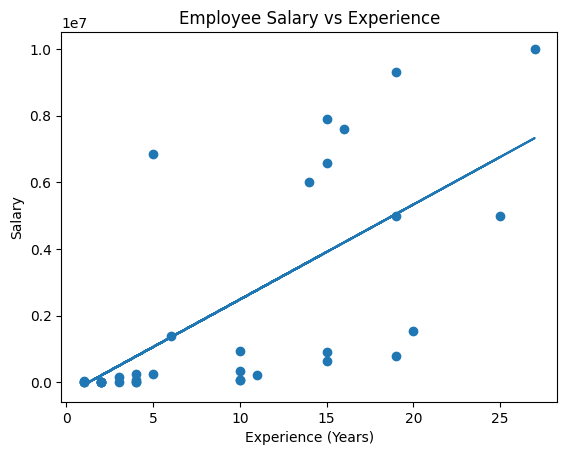

In [67]:
import matplotlib.pyplot as plt

# Show the actual employee data
plt.scatter(X, y)

# Draw the regression line
plt.plot(X, model.predict(X))

# Give names to the axes
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")

# Give a title to the graph
plt.title("Employee Salary vs Experience")

# Show the graph
plt.show()

In [68]:
# Give a new experience value
experience = 5

# Predict the salary
predicted_salary = model.predict([[experience]])

print("Experience:", experience, "years")
print("Predicted Salary:", predicted_salary[0])

Experience: 5 years
Predicted Salary: 1065550.634050389


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [69]:
from sklearn.linear_model import LinearRegression

# Create a new regression model for reverse prediction
reverse_model = LinearRegression()

# Use Salary as the independent variable
# Use Experience_Years as the dependent variable
reverse_model.fit(
    df[["Salary"]],
    df["Experience_Years"]
)

LinearRegression()

In [70]:
# Give a salary as input
salary = 50000

# Predict the experience
predicted_experience = reverse_model.predict([[salary]])

print("Salary:", salary)
print("Predicted Experience:", predicted_experience[0], "years")

Salary: 50000
Predicted Experience: 5.918117955599492 years


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


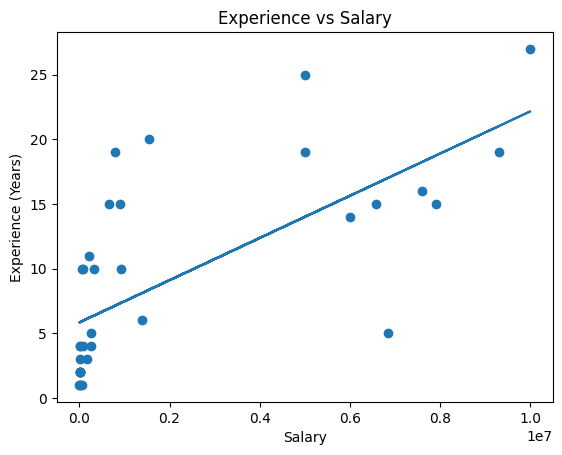

In [72]:
import matplotlib.pyplot as plt

# Show the actual data
plt.scatter(
    df["Salary"],
    df["Experience_Years"]
)

# Draw the regression line
plt.plot(
    df["Salary"],
    reverse_model.predict(df[["Salary"]])
)

# Give names to the axes
plt.xlabel("Salary")
plt.ylabel("Experience (Years)")

# Give a title to the graph
plt.title("Experience vs Salary")

# Show the graph
plt.show()